Jumlah data training : 21886
Jumlah data testing  : 5472

Mulai melatih Random Forest...
Training Selesai!

--- EVALUATION METRICS ---
                 precision    recall  f1-score   support

 Uninfected (0)       0.92      0.96      0.94      2724
Parasitized (1)       0.96      0.92      0.94      2748

       accuracy                           0.94      5472
      macro avg       0.94      0.94      0.94      5472
   weighted avg       0.94      0.94      0.94      5472



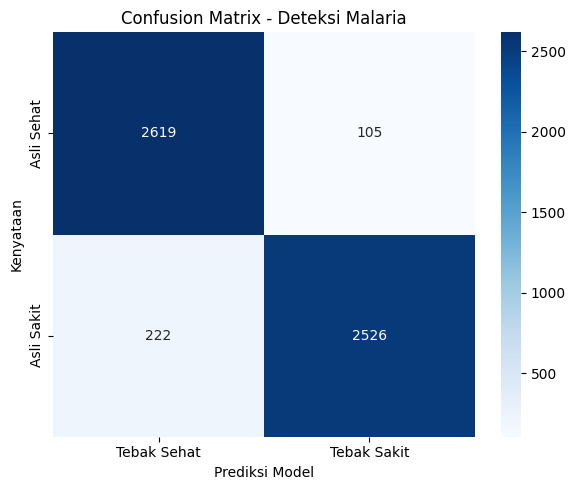

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('../extracted-csv/malaria_features.csv')

# Hapus baris yang mungkin error (area sel = 0)
df = df[df['cell_area'] > 0]

# PISAHIN FITUR (X) DAN LABEL (y)
# X adalah data yang dipakai untuk menebak (Luas sel, jumlah parasit, dll)
X = df[['cell_area', 'parasite_count', 'parasite_area', 'texture_contrast']]
y = df['label']

# DATA SPLITTING
# 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training : {len(X_train)}")
print(f"Jumlah data testing  : {len(X_test)}\n")

# MODEL INITIALIZATION
print("Mulai melatih Random Forest...")
# n_estimators=100 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train) 
print("Training Selesai!\n")

# PREDICT
y_pred = rf_model.predict(X_test)

# 6. EVALUASI HASILNYA
print("--- EVALUATION METRICS ---")
print(classification_report(y_test, y_pred, target_names=['Uninfected (0)', 'Parasitized (1)']))

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tebak Sehat', 'Tebak Sakit'], 
            yticklabels=['Asli Sehat', 'Asli Sakit'])
plt.title('Confusion Matrix - Deteksi Malaria')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan')
plt.tight_layout()
plt.show()

In [13]:
 # --- FEATURE IMPORTANCE ---
print("\n--- FEATURE IMPORTANCE ---")
importances = rf_model.feature_importances_
for feature, score in zip(X.columns, importances):
    print(f"{feature:<15} : {score:.2%}")


--- FEATURE IMPORTANCE ---
cell_area       : 9.15%
parasite_count  : 40.64%
parasite_area   : 41.31%
texture_contrast : 8.90%


In [14]:
import joblib

model_filename = 'malaria_rf_model.pkl'
joblib.dump(rf_model, model_filename)

print(f"Model berhasil disimpan sebagai: {model_filename}")

Model berhasil disimpan sebagai: malaria_rf_model.pkl
